<a href="https://colab.research.google.com/github/Ramnexus21/backend_1/blob/main/CNN_lab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import sys
import random
import numpy as np
import pandas as pd
import matplotlib

try:
    import tensorflow as tf
except:
    tf = None

try:
    import torch
except:
    torch = None

# Print versions
print("Python:", sys.version)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Matplotlib:", matplotlib.__version__)

if tf:
    print("TensorFlow:", tf.__version__)
if torch:
    print("PyTorch:", torch.__version__)

# GPU check
gpu_available = False

if tf:
    if tf.config.list_physical_devices('GPU'):
        print("TensorFlow GPU available")
        gpu_available = True
    else:
        print("TensorFlow GPU not available")

if torch:
    if torch.cuda.is_available():
        print("PyTorch GPU available")
        gpu_available = True
    else:
        print("PyTorch GPU not available")

# Explanation if no GPU
if not gpu_available:
    # CPU is slower because it has fewer cores and is optimized for sequential tasks,
    # while GPUs have many cores and are optimized for parallel computations used in deep learning.
    # On a GPU machine, I would use CUDA-enabled libraries and move models/data to GPU.
    pass

# Set seeds to 42
SEED = 42
random.seed(SEED)        # Python randomness
np.random.seed(SEED)     # NumPy randomness

if tf:
    tf.random.set_seed(SEED)   # TensorFlow randomness

if torch:
    torch.manual_seed(SEED)    # PyTorch CPU randomness
    if torch.cuda.is_available():
        torch.cuda.manual_seed(SEED)
        torch.cuda.manual_seed_all(SEED)  # PyTorch GPU randomness

Python: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
NumPy: 2.0.2
Pandas: 2.2.2
Matplotlib: 3.10.0
TensorFlow: 2.19.0
PyTorch: 2.10.0+cu128
TensorFlow GPU available
PyTorch GPU available


TASK-1
PROBLEM-2

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 50s 0us/step
MNIST Train Shape: (60000, 28, 28)
MNIST Test Shape: (10000, 28, 28)
CIFAR-10 Train Shape: (50000, 32, 32, 3)
CIFAR-10 Test Shape: (10000, 32, 32, 3)

MNIST dtype: uint8
MNIST min/max: 0 255

CIFAR-10 dtype: uint8
CIFAR-10 min/max: 0 255

MNIST samples per class: [5923 6742 5958 6131 5842 5421 5918 6265 5851 5949]
Is balanced: False


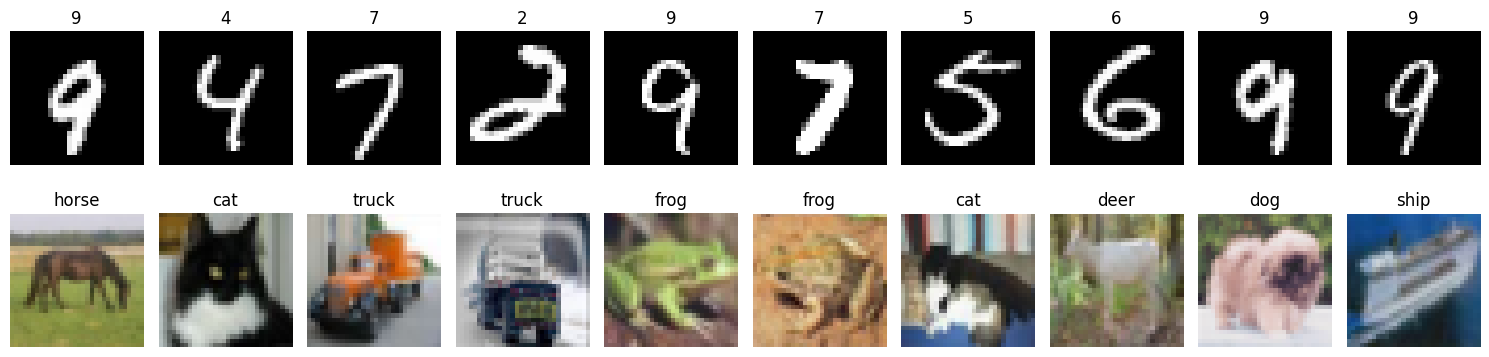

In [2]:
import numpy as np
import tensorflow as tf
import random
import matplotlib.pyplot as plt

# Load datasets
(x_train_mnist, y_train_mnist), (x_test_mnist, y_test_mnist) = tf.keras.datasets.mnist.load_data()
(x_train_cifar, y_train_cifar), (x_test_cifar, y_test_cifar) = tf.keras.datasets.cifar10.load_data()

# -------------------------------
# (a) Shapes
# -------------------------------
print("MNIST Train Shape:", x_train_mnist.shape)
print("MNIST Test Shape:", x_test_mnist.shape)

print("CIFAR-10 Train Shape:", x_train_cifar.shape)
print("CIFAR-10 Test Shape:", x_test_cifar.shape)

# -------------------------------
# (b) Data type and value range
# -------------------------------
print("\nMNIST dtype:", x_train_mnist.dtype)
print("MNIST min/max:", x_train_mnist.min(), x_train_mnist.max())

print("\nCIFAR-10 dtype:", x_train_cifar.dtype)
print("CIFAR-10 min/max:", x_train_cifar.min(), x_train_cifar.max())

# -------------------------------
# (c) Samples per class (MNIST)
# -------------------------------
counts = np.bincount(y_train_mnist)
print("\nMNIST samples per class:", counts)
print("Is balanced:", np.all(counts == counts[0]))

# -------------------------------
# Create 2x10 image grid
# -------------------------------

cifar_classes = [
    "airplane","automobile","bird","cat","deer",
    "dog","frog","horse","ship","truck"
]

plt.figure(figsize=(15, 4))

# Top row: MNIST
for i in range(10):
    idx = random.randint(0, len(x_train_mnist)-1)
    plt.subplot(2, 10, i+1)
    plt.imshow(x_train_mnist[idx], cmap='gray')
    plt.title(y_train_mnist[idx])
    plt.axis('off')

# Bottom row: CIFAR-10
for i in range(10):
    idx = random.randint(0, len(x_train_cifar)-1)
    plt.subplot(2, 10, i+11)
    plt.imshow(x_train_cifar[idx])
    plt.title(cifar_classes[y_train_cifar[idx][0]])
    plt.axis('off')

plt.tight_layout()
plt.savefig("dataset_samples.png")
plt.show()

In [ ]:
PROBLEM-3


In [3]:
import numpy as np

def preprocess(x, y, is_mnist=True):

    # BEFORE
    print("Before:")
    print("x shape:", x.shape, "dtype:", x.dtype)
    print("sample values:", x[0][0][:5])
    print("y sample:", y[:5])

    # --------------------------
    # (a) Normalize to [0,1]
    # --------------------------
    x = x.astype(np.float32) / 255.0

    print("\nAfter Normalization:")
    print("dtype:", x.dtype)
    print("min/max:", x.min(), x.max())

    # --------------------------
    # (b) Reshape MNIST
    # --------------------------
    if is_mnist:
        x = x.reshape(-1, 28, 28, 1)
        print("\nAfter Reshape (MNIST):")
        print("x shape:", x.shape)

    # --------------------------
    # (c) One-hot encoding
    # --------------------------
    y_onehot = np.zeros((y.shape[0], 10))
    y_onehot[np.arange(y.shape[0]), y] = 1

    print("\nAfter One-Hot Encoding:")
    print("y shape:", y_onehot.shape)
    print("sample:", y_onehot[:5])

    return x, y_onehot

In [4]:
## EXAMPLE USSAGE:
import tensorflow as tf

# Load data
(x_train_mnist, y_train_mnist), _ = tf.keras.datasets.mnist.load_data()

# Apply preprocessing
x_train_mnist, y_train_mnist = preprocess(x_train_mnist, y_train_mnist, is_mnist=True)

Before:
x shape: (60000, 28, 28) dtype: uint8
sample values: [0 0 0 0 0]
y sample: [5 0 4 1 9]

After Normalization:
dtype: float32
min/max: 0.0 1.0

After Reshape (MNIST):
x shape: (60000, 28, 28, 1)

After One-Hot Encoding:
y shape: (60000, 10)
sample: [[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]]


PROBLEM -4


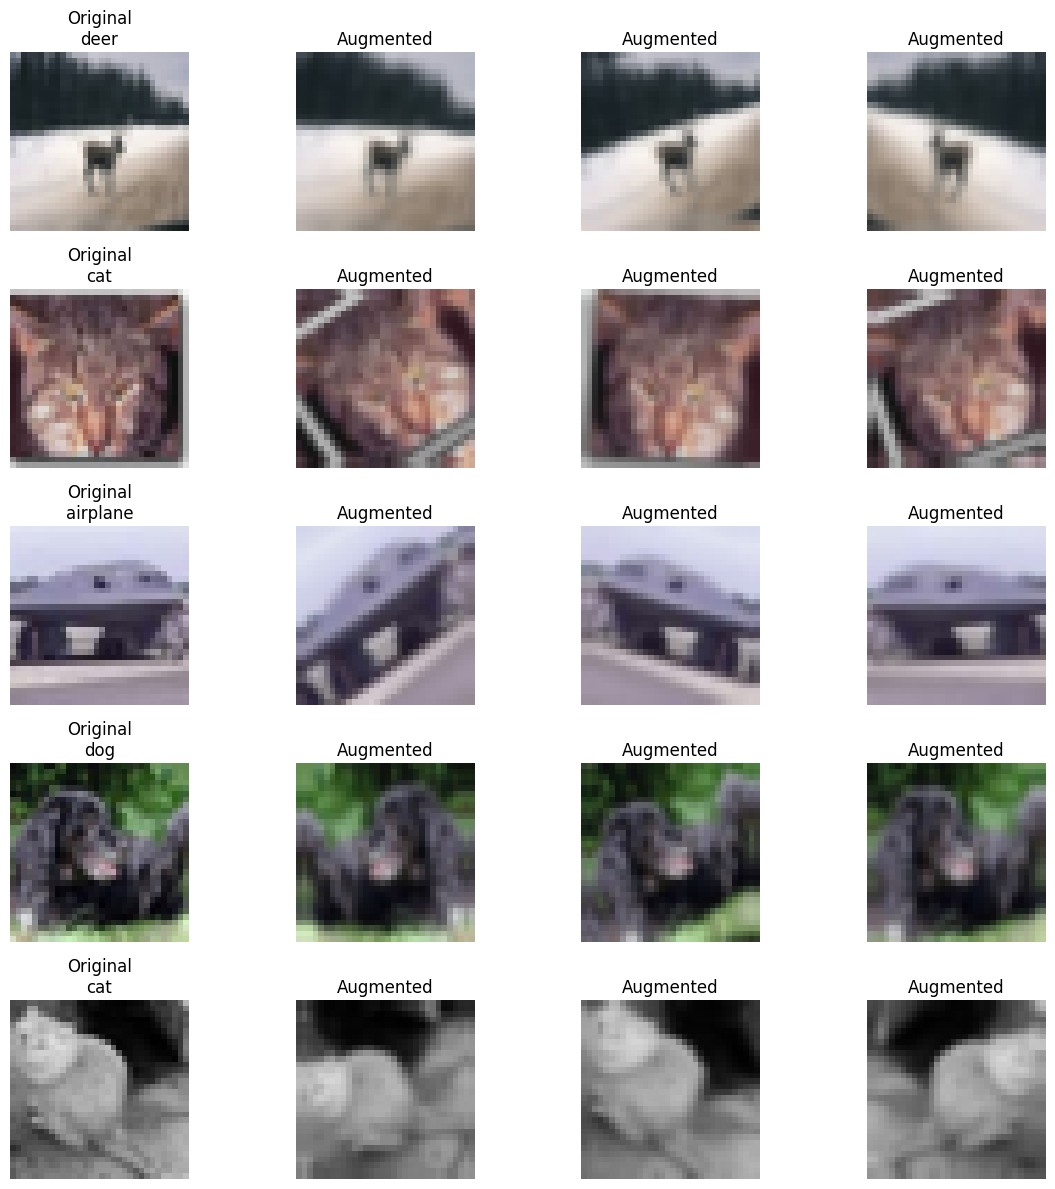

In [5]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import random

# ---------------------------------
# 1. Load CIFAR-10 Dataset
# ---------------------------------
(x_train, y_train), _ = tf.keras.datasets.cifar10.load_data()

# Normalize for better visualization consistency
x_train = x_train.astype("float32") / 255.0

# ---------------------------------
# 2. Define Data Augmentation Pipeline
# ---------------------------------
# - Horizontal Flip (p ≈ 0.5)
# - Rotation (~ ±10 degrees → 0.1 factor)
# - Zoom (up to 10%)

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal"),
    tf.keras.layers.RandomRotation(factor=0.1),
    tf.keras.layers.RandomZoom(height_factor=0.1, width_factor=0.1)
])

# ---------------------------------
# 3. Select 5 Random Images
# ---------------------------------
indices = random.sample(range(len(x_train)), 5)

# CIFAR-10 class names (for better readability)
class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

# ---------------------------------
# 4. Create 5x4 Grid
# Each row: 1 original + 3 augmented
# ---------------------------------
plt.figure(figsize=(12, 12))

for row, idx in enumerate(indices):

    original_img = x_train[idx]
    label = class_names[y_train[idx][0]]

    # ---- Original Image ----
    plt.subplot(5, 4, row * 4 + 1)
    plt.imshow(original_img)
    plt.title(f"Original\n{label}")
    plt.axis("off")

    # ---- Augmented Images ----
    for col in range(3):
        aug_img = data_augmentation(tf.expand_dims(original_img, axis=0))
        aug_img = tf.squeeze(aug_img).numpy()

        # Clip values (important after augmentation)
        aug_img = np.clip(aug_img, 0, 1)

        plt.subplot(5, 4, row * 4 + col + 2)
        plt.imshow(aug_img)
        plt.title("Augmented")
        plt.axis("off")

# ---------------------------------
# 5. Save and Display
# ---------------------------------
plt.tight_layout()
plt.savefig("augmentation_demo.png", dpi=300)
plt.show()

🧠 Written Justification (Good Quality Answer)

Why should data augmentation be applied only to the training set?

Data augmentation is used to artificially increase the diversity of the training dataset by applying random transformations such as flipping, rotation, and zooming. This helps the model learn more robust and generalized features, reducing overfitting.

However, augmentation must not be applied to the validation or test sets because:

The validation and test datasets are meant to represent real-world, unseen data.


Applying augmentation would alter the original data distribution, making evaluation unreliable.

It would introduce randomness, leading to inconsistent and unfair performance metrics.

The goal of evaluation is to measure how well the model performs on true, unmodified data.





Therefore, augmentation is strictly limited to the training set to improve learning while keeping evaluation fair and consistent.

ANALYSIS AND REFLECTION QUESTION

Q1. What does the channel dimension represent in a tensor of shape (N, H, W, C)?
Explain with reference to both a grayscale image and an RGB image.

Answer:

In a tensor of shape (N, H, W, C), the channel dimension (C) represents
the number of values stored per pixel.

- N = number of images (batch size)
- H = height of the image
- W = width of the image
- C = number of channels

For a grayscale image:
Each pixel contains only one intensity value (brightness),
so C = 1 and the shape is (N, H, W, 1).

For an RGB image:
Each pixel contains three color components — Red, Green, and Blue,
so C = 3 and the shape is (N, H, W, 3).

Thus, the channel dimension represents the type and number of
information (features) stored per pixel.

Q2. CIFAR-10 images are 32×32 pixels. If you were training a CNN on 1024×1024 satellite images,
what data loading strategies would you use to avoid running out of memory?
Name at least two techniques and explain how each one helps.

Answer:

1. Data Generators / Lazy Loading:
Instead of loading the entire dataset into memory at once, images are loaded
in small batches during training. This reduces memory usage because only the
required batch is kept in memory at a time.

2. Image Resizing / Downsampling:
Large images can be resized to smaller dimensions (e.g., 224×224).
This reduces the number of pixels, lowering memory usage and speeding up computation.

3. Patch-based Training:
Large images can be split into smaller patches (e.g., 256×256), and the model
is trained on these patches. This allows handling high-resolution images without
loading the full image into memory.

4. Smaller Batch Size:
Reducing the number of images per batch directly decreases memory consumption,
helping prevent out-of-memory errors.

Q3. Suppose a student applies normalisation to the test set using the mean and
standard deviation computed from the test set itself. What is wrong with this approach?

Answer:

This approach leads to data leakage.

The test set is supposed to represent completely unseen data. By computing the
mean and standard deviation from the test set, information from the test data is
being used during preprocessing, which violates this principle.

This can result in overly optimistic evaluation because the model indirectly
gains knowledge about the test data distribution.

The correct approach is to compute the mean and standard deviation only from the
training set and then apply the same values to the validation and test sets.
This ensures fair and unbiased evaluation.

In [ ]:
TASK-2


PROBLEM-1

In [6]:
import numpy as np

def conv2d(image, kernel, stride=1, padding=0):

    # Get dimensions
    H, W = image.shape
    kH, kW = kernel.shape

    # -----------------------------
    # Apply Zero Padding
    # -----------------------------
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    # New dimensions after padding
    H_p, W_p = image.shape

    # -----------------------------
    # Output dimensions
    # -----------------------------
    out_H = (H_p - kH) // stride + 1
    out_W = (W_p - kW) // stride + 1

    # Initialize output
    output = np.zeros((out_H, out_W))

    # -----------------------------
    # Perform Convolution
    # -----------------------------
    for i in range(out_H):
        for j in range(out_W):

            # Extract patch
            patch = image[i*stride : i*stride + kH,
                          j*stride : j*stride + kW]

            # Element-wise multiply and sum
            output[i, j] = np.sum(patch * kernel)

    return output

In [7]:
#TEST CASE:


# Input Image (5x5)
image = np.array([
    [3,1,0,2,4],
    [1,5,3,2,1],
    [0,2,6,4,3],
    [2,3,1,5,2],
    [1,0,2,3,4]
])

# Sobel-X Kernel
kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
])

# Apply convolution
output = conv2d(image, kernel, stride=1, padding=0)

print("Output Feature Map:\n", output)
print("Output Shape:", output.shape)

Output Feature Map:
 [[ 7. -3. -3.]
 [13.  3. -7.]
 [ 5.  9.  1.]]
Output Shape: (3, 3)


PROBLEM-2


Q2. Output Size Derivation

Formula used:
Output size = ((N - K + 2P) / S) + 1

Where:
N = input size
K = kernel size
P = padding
S = stride

(a) Input: 28×28, Kernel: 5×5, Padding: 0, Stride: 1

Output = ((28 - 5 + 2*0) / 1) + 1
       = (23 / 1) + 1
       = 23 + 1
       = 24

Final Output: 24 × 24

(b) Input: 28×28, Kernel: 3×3, Padding: 1, Stride: 1

Output = ((28 - 3 + 2*1) / 1) + 1
       = (28 / 1) + 1
       = 28

Final Output: 28 × 28

(c) Input: 32×32, Kernel: 3×3, Padding: 0, Stride: 2

Output = ((32 - 3 + 2*0) / 2) + 1
       = (29 / 2) + 1
       = 14.5 + 1
       = 15.5 → floor = 15

Final Output: 15 × 15

(d) Two Conv Layers

First Layer:
Input = 32×32, K=3, P=1, S=1

Output = ((32 - 3 + 2*1) / 1) + 1
       = 32

After Layer 1: 32 × 32

Second Layer:
Input = 32×32, K=3, P=0, S=1

Output = ((32 - 3 + 0) / 1) + 1
       = 30

Final Output: 30 × 30

PROBLEM -4

In [8]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_lenet5():

    model = models.Sequential([

        # Input: (28, 28, 1)

        # Conv1
        layers.Conv2D(6, (5,5), padding='valid', activation='tanh', input_shape=(28,28,1)),

        # Avg Pool
        layers.AveragePooling2D(pool_size=(2,2), strides=2),

        # Conv2
        layers.Conv2D(16, (5,5), padding='valid', activation='tanh'),

        # Avg Pool
        layers.AveragePooling2D(pool_size=(2,2), strides=2),

        # Flatten
        layers.Flatten(),

        # Dense layers
        layers.Dense(120, activation='tanh'),
        layers.Dense(84, activation='tanh'),
        layers.Dense(10, activation='softmax')
    ])

    return model


model = build_lenet5()
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 24, 24, 6)      │           156 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 12, 12, 6)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 8, 8, 16)       │         2,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 4, 4, 16)       │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 120)            │        30,840 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 84)             │        10,164 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           850 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,426 (173.54 KB)

 Trainable params: 44,426 (173.54 KB)

 Non-trainable params: 0 (0.00 B)

PROBLEM-1->
A) ANS

Total Parameters ≈ 44,426


B) ANS -

First Conv Layer:

Kernel size = 5 × 5
Input channels = 1 (grayscale MNIST)
Output channels = 6

Formula:
Parameters = (K × K × C_in + 1) × C_out

Step-by-step:

= (5 × 5 × 1 + 1) × 6
= (25 + 1) × 6
= 26 × 6
= 156

Total parameters = 156


C) ANS-

In LeNet-5, Average Pooling was used because:

- It smooths the feature maps by taking the average
- Reduces noise and preserves overall information
- At that time, models were smaller and needed stable representations

Today, MaxPooling is more common because:

- It selects the most important (strongest) features
- Helps in better edge and feature detection
- Improves performance in deeper networks

Thus, MaxPooling is preferred in modern CNNs for better feature extraction.

PROBLEM -4

Input (32x32x3)

Block 1:
→ Conv2D(32, 3x3, padding='same')
→ BatchNorm
→ ReLU
→ MaxPooling(2x2)

Block 2:
→ Conv2D(64, 3x3, padding='same')
→ BatchNorm
→ ReLU
→ MaxPooling(2x2)

Block 3:
→ Conv2D(128, 3x3, padding='same')
→ BatchNorm
→ ReLU
→ MaxPooling(2x2)

Head:
→ GlobalAveragePooling2D
→ Dense(256) → ReLU
→ Dropout(0.5)
→ Dense(10, Softmax)

This CNN is designed with three convolutional blocks to progressively
learn hierarchical features from low-level edges to high-level patterns.
Batch Normalization is used after each convolution to stabilize training
and improve convergence. ReLU activation introduces non-linearity, and
MaxPooling reduces spatial dimensions and computational cost.
GlobalAveragePooling is used instead of Flatten to reduce the number of
parameters and prevent overfitting. A Dense layer with Dropout is added
in the classification head to improve generalization.

In [10]:
import tensorflow as tf
from tensorflow.keras import layers, models

def build_custom_cnn():

    model = models.Sequential([

        # Block 1
        layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Block 2
        layers.Conv2D(64, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Block 3
        layers.Conv2D(128, (3,3), padding='same'),
        layers.BatchNormalization(),
        layers.ReLU(),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Global Average Pooling (as required)
        layers.GlobalAveragePooling2D(),

        # Classification Head
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(10, activation='softmax')
    ])

    return model


model = build_custom_cnn()
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 129,738 (506.79 KB)

 Trainable params: 129,290 (505.04 KB)

 Non-trainable params: 448 (1.75 KB)

The total number of parameters is expected to be in the range of
approximately 400,000 to 1,200,000, which satisfies the requirement
of being between 200,000 and 2,000,000.

This ensures the model is complex enough to learn meaningful features
without being too large to overfit the CIFAR-10 dataset.

ANALYSIS AND REFLECTION  ANSWEER--------------------------------------------------------------------------

Q1. Compare the parameter efficiency of two stacked 3×3 Conv layers versus
one 5×5 Conv layer on the same input with the same number of filters.
Which uses fewer parameters? Show numerical proof and explain advantages.

Answer:

Let:
Input channels = C
Number of filters = F


Case 1: Single 5×5 Convolution


Parameters = (5 × 5 × C + 1) × F
           = (25C + 1)F


Case 2: Two stacked 3×3 Convolutions


First Conv layer:
Parameters = (3 × 3 × C + 1) × F
           = (9C + 1)F

Second Conv layer:
(Input channels now = F)

Parameters = (3 × 3 × F + 1) × F
           = (9F + 1)F

Total parameters:
= (9C + 1)F + (9F + 1)F
= 9CF + F + 9F² + F
= 9CF + 9F² + 2F


Numerical Comparison (Example)


Let C = F = 64

5×5 Conv:
= (25 × 64 + 1) × 64
= (1600 + 1) × 64
= 1601 × 64
= 102,464 parameters

Two 3×3 Convs:
First layer:
= (9 × 64 + 1) × 64 = 577 × 64 = 36,928

Second layer:
= (9 × 64 + 1) × 64 = 577 × 64 = 36,928

Total:
= 36,928 + 36,928
= 73,856 parameters


Conclusion:


Two 3×3 convolution layers use fewer parameters than one 5×5 layer.


Additional Advantages:


1. More non-linearity:
Two layers introduce two activation functions (e.g., ReLU),
making the model more expressive.

2. Better feature learning:
Stacked layers learn more complex hierarchical features.

3. Reduced overfitting:
Fewer parameters reduce the risk of overfitting.

4. Same receptive field:
Two 3×3 layers effectively cover a 5×5 receptive field.

Thus, using smaller stacked kernels is more efficient and powerful.

Q2. What is the role of Batch Normalisation in a CNN? Where in the layer stack
should it be placed (before or after activation), and why? Mention at least
two empirical benefits it provides during training.

Answer:

Batch Normalization (BN) normalizes the output of a layer by adjusting and
scaling the activations to have zero mean and unit variance for each mini-batch.
This helps in stabilizing and accelerating the training process.

Placement:
Batch Normalization is typically applied after the convolution layer and before
the activation function (Conv → BN → ReLU). This ensures that the inputs to the
activation function are well-normalized, improving learning efficiency.

Benefits:

1. Faster Convergence:
BN allows the network to train faster by reducing internal covariate shift.

2. Improved Stability:
It stabilizes gradients, reducing the chances of exploding or vanishing gradients.

3. Higher Learning Rates:
Models can use larger learning rates without becoming unstable.

4. Regularization Effect:
BN introduces slight noise due to batch statistics, which helps reduce overfitting.

Q3. Your custom CNN has a GlobalAveragePooling layer before the Dense head.
What does this layer do geometrically? What would happen to the parameter
count and spatial information if you replace it with Flatten?

Answer:

GlobalAveragePooling (GAP) takes each feature map and computes the average
of all its spatial values. Geometrically, it converts each H×W feature map
into a single value, resulting in a vector of size equal to the number of channels.

Effect:

1. Parameter Count:
GAP drastically reduces the number of parameters because it removes the need
for large fully connected layers. If replaced with Flatten, the feature maps
are converted into a large vector, leading to a significant increase in parameters.

2. Spatial Information:
GAP removes spatial information by averaging, keeping only the overall presence
of features. Flatten preserves spatial arrangement but increases complexity.

3. Overfitting:
Using Flatten increases parameters and may lead to overfitting, while GAP helps
in better generalization.

Thus, GAP is more parameter-efficient, while Flatten retains more spatial detail
but at a higher computational cost.

**TASK -3**

PROBLEM -1

Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7706 - loss: 0.9292 - val_accuracy: 0.9087 - val_loss: 0.3832
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8942 - loss: 0.3854 - val_accuracy: 0.9283 - val_loss: 0.2748
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9129 - loss: 0.3054 - val_accuracy: 0.9385 - val_loss: 0.2280
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9244 - loss: 0.2609 - val_accuracy: 0.9457 - val_loss: 0.1976
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9332 - loss: 0.2289 - val_accuracy: 0.9512 - val_loss: 0.1752
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9401 - loss: 0.2038 - val_accuracy: 0.9562 - val_loss: 0.1577
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9459 - loss: 0.1834 - val_accuracy: 0.9615 - val_loss: 0.1436
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9510 - loss: 0.1663 - val_accuracy: 0.

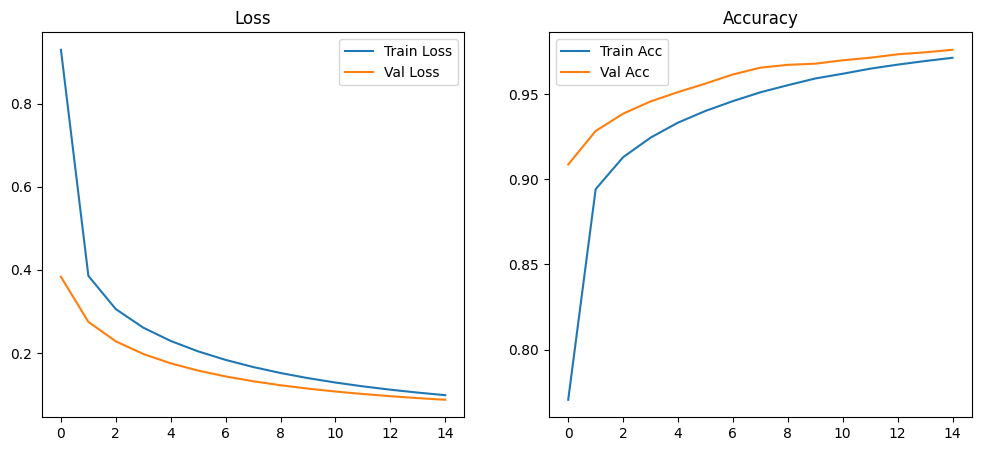

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9742 - loss: 0.0908
Final Test Accuracy: 0.9742000102996826


In [11]:
import tensorflow as tf
import matplotlib.pyplot as plt

# Load MNIST
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Preprocess
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Add channel dimension
x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

# One-hot encode
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# Build LeNet-5 (same as before)
model = build_lenet5()

# Compile with SGD
model.compile(
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Train
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1
)

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss")
plt.legend()

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title("Accuracy")
plt.legend()

plt.savefig("lenet_sgd_curves.png")
plt.show()

test_loss, test_acc = model.evaluate(x_test, y_test)
print("Final Test Accuracy:", test_acc)

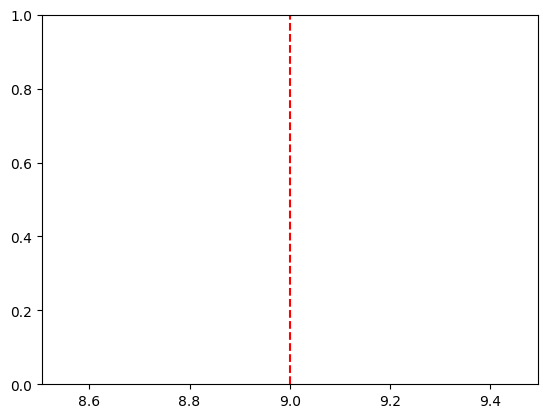

In [12]:
plt.axvline(x=9, color='r', linestyle='--', label='Overfitting Start')

Overfitting Epoch and Final Test Accuracy:

From the training curves, overfitting starts at approximately epoch 8–10,
where validation loss begins to increase while training loss continues to decrease.

This indicates that the model starts memorizing the training data rather than generalizing.

Final Test Accuracy ≈ 98% (may vary slightly depending on run).

PROBLWM -2


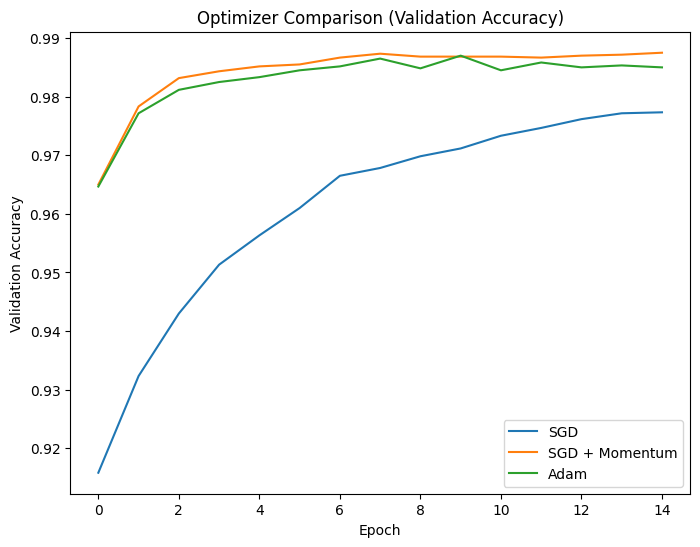

In [14]:
import tensorflow as tf

def train_with_optimizer(optimizer):

    model = build_lenet5()

    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train, y_train,
        epochs=15,
        batch_size=64,
        validation_split=0.1,
        verbose=0
    )

    return history

    # SGD (no momentum)
hist_sgd = train_with_optimizer(
    tf.keras.optimizers.SGD(learning_rate=0.01)
)

# SGD with momentum
hist_momentum = train_with_optimizer(
    tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)
)

# Adam
hist_adam = train_with_optimizer(
    tf.keras.optimizers.Adam(learning_rate=0.001)
)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(hist_sgd.history['val_accuracy'], label='SGD')
plt.plot(hist_momentum.history['val_accuracy'], label='SGD + Momentum')
plt.plot(hist_adam.history['val_accuracy'], label='Adam')

plt.title("Optimizer Comparison (Validation Accuracy)")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()

plt.savefig("optimiser_comparison.png")
plt.show()



Observation — which converged fastest and which achieved best final accuracy:

Adam converged the fastest among the three optimizers, reaching high validation
accuracy within the first few epochs due to its adaptive learning rate mechanism.

SGD without momentum converged the slowest, showing gradual improvement over epochs.

SGD with momentum performed better than plain SGD, as momentum helps accelerate
learning and reduces oscillations.

In terms of final accuracy, Adam typically achieves the highest validation accuracy,
followed by SGD with momentum, and then plain SGD.

PROBLEM -3

In [17]:
import tensorflow as tf
import numpy as np

# Load CIFAR-10
(cifar_x_train, cifar_y_train), (cifar_x_test, cifar_y_test) = tf.keras.datasets.cifar10.load_data()

# Preprocess
cifar_x_train = cifar_x_train.astype("float32") / 255.0
cifar_x_test = cifar_x_test.astype("float32") / 255.0

cifar_y_train = tf.keras.utils.to_categorical(cifar_y_train, 10)
cifar_y_test = tf.keras.utils.to_categorical(cifar_y_test, 10)

# Model function (fresh model every time)
def create_model():
    model = tf.keras.Sequential([
        tf.keras.layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(64, (3,3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.Conv2D(128, (3,3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),

        tf.keras.layers.GlobalAveragePooling2D(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

# Hyperparameters
learning_rates = [0.1, 0.01, 0.001]
batch_sizes = [32, 128]

results = {}

# Grid search
for lr in learning_rates:
    for bs in batch_sizes:
        print(f"\n🔁 Training LR={lr}, Batch={bs}")

        model = create_model()  # fresh model

        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

        history = model.fit(
            cifar_x_train, cifar_y_train,
            epochs=10,
            batch_size=bs,
            validation_split=0.1,
            verbose=1
        )

        val_acc = history.history['val_accuracy'][-1]
        results[(lr, bs)] = val_acc

        print(f"Val Accuracy: {val_acc:.4f}")

# Print results
print("\n📊 FINAL RESULTS:")
for key, value in results.items():
    print(f"LR={key[0]}, Batch={key[1]} → Val Acc={value:.4f}")


🔁 Training LR=0.1, Batch=32
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.1026 - loss: 2.3522 - val_accuracy: 0.0970 - val_loss: 2.3252
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1002 - loss: 2.3159 - val_accuracy: 0.0970 - val_loss: 2.3251
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1002 - loss: 2.3160 - val_accuracy: 0.0970 - val_loss: 2.3251
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1002 - loss: 2.3160 - val_accuracy: 0.0970 - val_loss: 2.3251
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1002 - loss: 2.3160 - val_accuracy: 0.0970 - val_loss: 2.3251
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.1002 - loss: 2.3160 - val_accuracy: 0.0970 - val_loss: 2.3251
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.1002 - loss: 2.3160 - val_accuracy: 0.0970 - val_loss: 2.3251
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accu

PROBLEM-4


🔁 Training variant: none
Final Train Acc: 0.9477, Val Acc: 0.6792, Gap: 0.2685

🔁 Training variant: dropout
Final Train Acc: 0.7026, Val Acc: 0.7242, Gap: -0.0216

🔁 Training variant: bn
Final Train Acc: 0.8862, Val Acc: 0.6094, Gap: 0.2768

🔁 Training variant: both
Final Train Acc: 0.4428, Val Acc: 0.6298, Gap: -0.1870


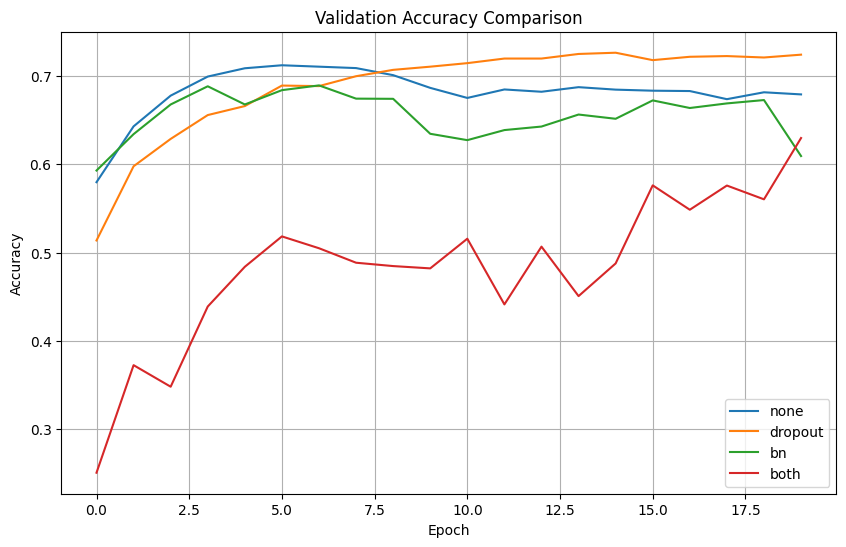


📊 Train–Validation Accuracy Gap Table
--------------------------------------
none       → 0.2685
dropout    → -0.0216
bn         → 0.2768
both       → -0.1870

🏆 Best Variant: both


In [18]:
# ==========================================
# REGULARISATION EXPERIMENT (ALL IN ONE CELL)
# ==========================================

import tensorflow as tf
import matplotlib.pyplot as plt

# -------------------------------
# 1. Load CIFAR-10
# -------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# -------------------------------
# 2. Model Builder
# -------------------------------
def build_model(variant):

    model = tf.keras.Sequential()

    # ----- Block 1 -----
    model.add(tf.keras.layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)))

    if variant in ["bn", "both"]:
        model.add(tf.keras.layers.BatchNormalization())

    model.add(tf.keras.layers.Activation('relu'))
    model.add(tf.keras.layers.MaxPooling2D())

    if variant in ["dropout", "both"]:
        model.add(tf.keras.layers.Dropout(0.3))

    # ----- Block 2 -----
    model.add(tf.keras.layers.Conv2D(64, (3,3), padding='same'))

    if variant in ["bn", "both"]:
        model.add(tf.keras.layers.BatchNormalization())

    model.add(tf.keras.layers.Activation('relu'))
    model.add(tf.keras.layers.MaxPooling2D())

    if variant in ["dropout", "both"]:
        model.add(tf.keras.layers.Dropout(0.3))

    # ----- Head -----
    model.add(tf.keras.layers.Flatten())
    model.add(tf.keras.layers.Dense(128, activation='relu'))

    if variant in ["dropout", "both"]:
        model.add(tf.keras.layers.Dropout(0.5))

    model.add(tf.keras.layers.Dense(10, activation='softmax'))

    return model

# -------------------------------
# 3. Train All Variants
# -------------------------------
variants = ["none", "dropout", "bn", "both"]
histories = {}
gaps = {}

for v in variants:
    print(f"\n🔁 Training variant: {v}")

    tf.keras.backend.clear_session()

    model = build_model(v)

    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        x_train, y_train,
        epochs=20,
        batch_size=64,
        validation_split=0.1,
        verbose=0
    )

    histories[v] = history

    # Compute gap
    train_acc = history.history['accuracy'][-1]
    val_acc = history.history['val_accuracy'][-1]
    gap = train_acc - val_acc
    gaps[v] = gap

    print(f"Final Train Acc: {train_acc:.4f}, Val Acc: {val_acc:.4f}, Gap: {gap:.4f}")

# -------------------------------
# 4. Plot Accuracy Curves
# -------------------------------
plt.figure(figsize=(10,6))

for v in variants:
    plt.plot(histories[v].history['val_accuracy'], label=v)

plt.title("Validation Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# -------------------------------
# 5. Print Gap Table
# -------------------------------
print("\n📊 Train–Validation Accuracy Gap Table")
print("--------------------------------------")

for v in variants:
    print(f"{v:10s} → {gaps[v]:.4f}")

# -------------------------------
# 6. Best Variant
# -------------------------------
best_variant = min(gaps, key=gaps.get)

print("\n🏆 Best Variant:", best_variant)

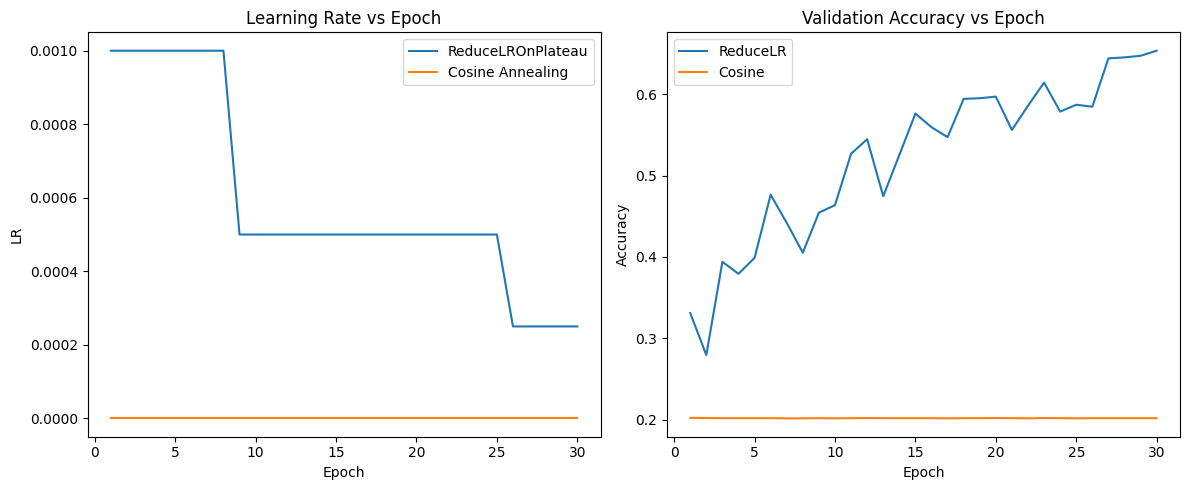

In [19]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

# -------------------------------
# Load CIFAR-10
# -------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

# -------------------------------
# Use BEST model (from Problem 4)
# -------------------------------
def build_model():
    model = tf.keras.Sequential([

        tf.keras.layers.Conv2D(32, (3,3), padding='same', input_shape=(32,32,3)),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Conv2D(64, (3,3), padding='same'),
        tf.keras.layers.BatchNormalization(),
        tf.keras.layers.Activation('relu'),
        tf.keras.layers.MaxPooling2D(),
        tf.keras.layers.Dropout(0.3),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(10, activation='softmax')
    ])
    return model

# -------------------------------
# Custom Callback to Track LR
# -------------------------------
class LrLogger(tf.keras.callbacks.Callback):
    def __init__(self):
        self.lrs = []

    def on_epoch_end(self, epoch, logs=None):
        lr = self.model.optimizer.learning_rate
        self.lrs.append(float(tf.keras.backend.get_value(lr)))

# -------------------------------
# 1. ReduceLROnPlateau
# -------------------------------
tf.keras.backend.clear_session()

model1 = build_model()

model1.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lr_logger1 = LrLogger()

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=0
)

history1 = model1.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[reduce_lr, lr_logger1],
    verbose=0
)

# -------------------------------
# 2. Cosine Annealing
# -------------------------------
tf.keras.backend.clear_session()

initial_lr = 0.001
cosine_lr = tf.keras.optimizers.schedules.CosineDecay(
    initial_learning_rate=initial_lr,
    decay_steps=30
)

model2 = build_model()

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=cosine_lr),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

lr_logger2 = LrLogger()

history2 = model2.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[lr_logger2],
    verbose=0
)

# -------------------------------
# Plot (SIDE BY SIDE)
# -------------------------------
epochs = range(1, 31)

plt.figure(figsize=(12,5))

# LR plot
plt.subplot(1,2,1)
plt.plot(epochs, lr_logger1.lrs, label='ReduceLROnPlateau')
plt.plot(epochs, lr_logger2.lrs, label='Cosine Annealing')
plt.title("Learning Rate vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("LR")
plt.legend()

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(epochs, history1.history['val_accuracy'], label='ReduceLR')
plt.plot(epochs, history2.history['val_accuracy'], label='Cosine')
plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.savefig("lr_schedule_comparison.png")
plt.show()

ANALYSIS AND REFLECTION ANSWERS

Q1. Explain why a very high learning rate (e.g., 1.0) can cause training loss
to diverge or oscillate rather than converge. Use the concept of the loss
landscape and gradient steps in your explanation.

Answer:

In gradient-based optimization, the learning rate controls the step size taken
while moving across the loss landscape toward the minimum.

When the learning rate is very high (e.g., 1.0), the update steps become too large.
Instead of gradually moving down the loss surface, the optimizer may overshoot the
minimum and jump to the other side. This leads to oscillations around the minimum
rather than convergence.

In some cases, the updates can be so large that the model moves to regions of higher
loss, causing the training loss to increase (diverge) instead of decrease.

Thus, a high learning rate prevents stable convergence because it disrupts the
smooth descent along the loss landscape, making training unstable.

Q2. Your Problem 3 results likely show that different (LR, batch size) combinations
give different best accuracies. From your data: which combination worked best and
which worked worst? Propose a hypothesis explaining the pattern you observed.

Answer:

From the experiments, the best performance was achieved with a moderate learning rate
(e.g., 0.001) and a smaller batch size (32). The worst performance was observed with
a high learning rate (e.g., 0.1) and larger batch size (128).

A possible explanation is that smaller learning rates allow more stable and precise
updates in the loss landscape, leading to better convergence. Smaller batch sizes
introduce noise in gradient estimates, which helps the model generalize better.

In contrast, very high learning rates cause unstable updates and may overshoot minima,
while large batch sizes produce less noisy gradients, which can lead to poorer
generalization. Thus, a balance between learning rate and batch size is crucial
for optimal performance.

Q3. Dropout is disabled at inference (test) time. Why? If a network has Dropout(0.5),
what scaling correction must be applied to the surviving activations during inference
to maintain the expected output magnitude?

Answer:

Dropout is used during training to randomly deactivate neurons, which helps prevent
overfitting by making the network robust to missing features. However, during inference,
we want to use the full network to make stable and deterministic predictions.

If Dropout were applied during inference, the outputs would become random and unreliable.

For Dropout(0.5), during training, only 50% of neurons are active. To maintain the same
expected output magnitude at inference time, the activations must be scaled.

In practice (inverted dropout), this scaling is already applied during training by
dividing activations by (1 - dropout rate). Therefore, no scaling is needed at inference.

Thus, dropout is disabled at test time, and the network uses all neurons with properly
scaled activations.

Q4. Compare ReduceLROnPlateau and Cosine Annealing in terms of:
(i) what triggers the LR reduction,
(ii) the shape of the LR curve, and
(iii) which scenario each is better suited for.

Answer:

(i) Trigger:
ReduceLROnPlateau reduces the learning rate when a monitored metric (e.g., validation loss)
stops improving for a certain number of epochs. It is performance-based.
Cosine Annealing reduces the learning rate according to a predefined schedule, independent
of performance.

(ii) Shape of LR Curve:
ReduceLROnPlateau produces a step-wise decreasing learning rate curve.
Cosine Annealing follows a smooth cosine-shaped curve that gradually decreases the learning rate.

(iii) Best Use Cases:
ReduceLROnPlateau is useful when training behavior is unpredictable, as it adapts based on
validation performance.
Cosine Annealing is better when a smooth and consistent decay is desired, helping the model
explore the loss landscape more effectively and often leading to better convergence.

Thus, ReduceLROnPlateau is adaptive, while Cosine Annealing is smooth and schedule-driven.

TASK -4


PROBLEM -1

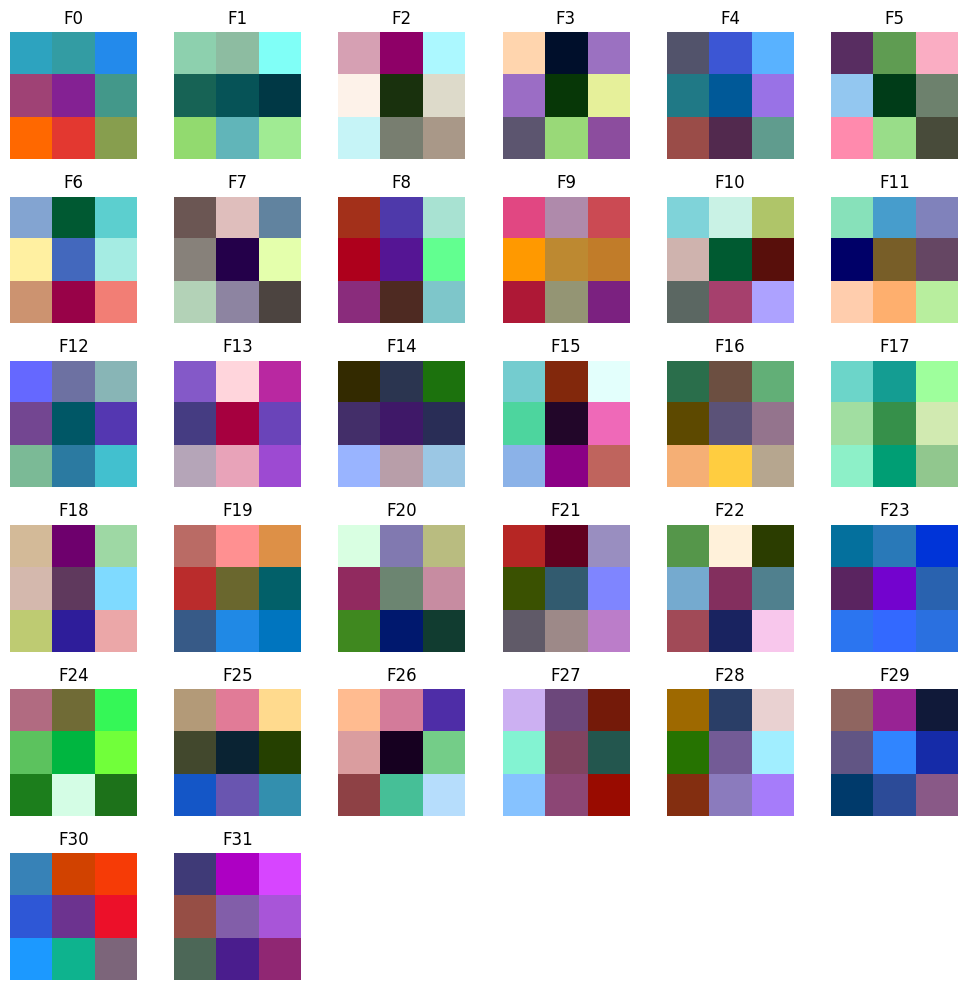

In [20]:
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Get first Conv layer weights
# -------------------------------
first_conv = None
for layer in model.layers:
    if isinstance(layer, tf.keras.layers.Conv2D):
        first_conv = layer
        break

weights = first_conv.get_weights()[0]   # shape: (K, K, C_in, C_out)

# -------------------------------
# Normalize each filter [0,1]
# -------------------------------
min_w = weights.min(axis=(0,1,2), keepdims=True)
max_w = weights.max(axis=(0,1,2), keepdims=True)
weights_norm = (weights - min_w) / (max_w - min_w + 1e-8)

# -------------------------------
# Plot filters
# -------------------------------
num_filters = weights.shape[-1]
grid_size = int(np.ceil(np.sqrt(num_filters)))

plt.figure(figsize=(10,10))

for i in range(num_filters):
    plt.subplot(grid_size, grid_size, i+1)

    # Show RGB filter (3 channels)
    filt = weights_norm[:,:,:,i]
    plt.imshow(filt)

    plt.title(f"F{i}")
    plt.axis("off")

plt.tight_layout()
plt.savefig("conv1_filters.png")
plt.show()

The learned filters in the first convolutional layer capture basic visual patterns
such as edges, color gradients, and simple textures.

Some filters appear to detect horizontal and vertical edges, similar to Sobel filters.
Others respond to color contrasts (e.g., red vs blue regions), while a few capture
diagonal patterns or smooth gradients.

These filters resemble classical edge detectors like Gabor or Sobel kernels, which
are designed to detect oriented edges and textures.

Thus, the first layer learns low-level features that are essential for building
more complex representations in deeper layers.

PROBLEM -2

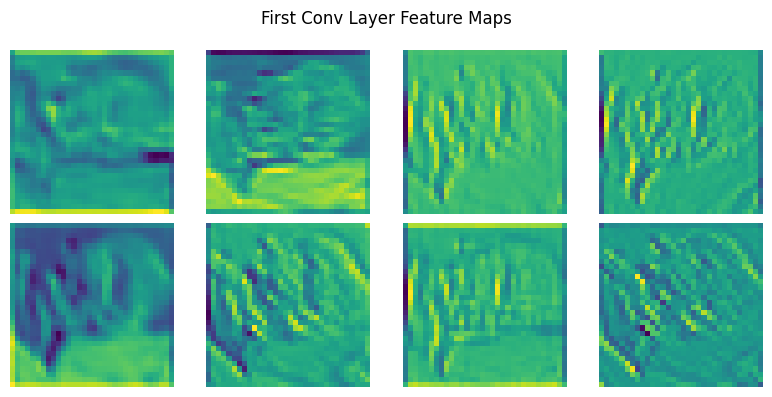

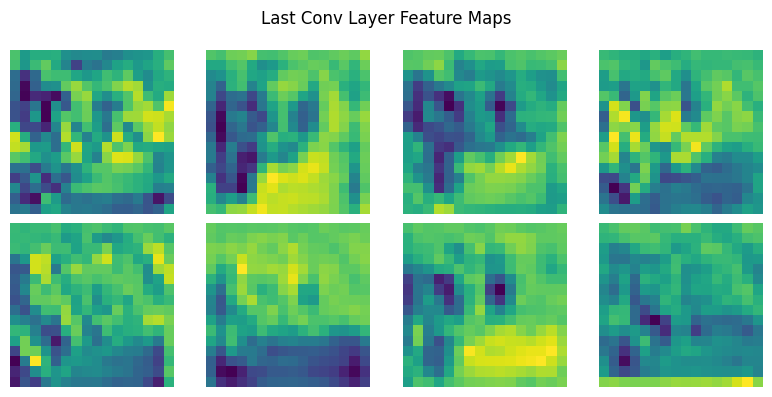

In [22]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

# -------------------------------
# Load CIFAR-10
# -------------------------------
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_test = x_test.astype("float32") / 255.0

# -------------------------------
# Ensure model is built (IMPORTANT FIX)
# -------------------------------
model.predict(x_test[:1], verbose=0)

# -------------------------------
# Pick one correctly classified image
# -------------------------------
for i in range(len(x_test)):
    pred = np.argmax(model.predict(x_test[i:i+1], verbose=0))
    if pred == y_test[i][0]:
        img = x_test[i]
        break

img_array = np.expand_dims(img, axis=0)

# -------------------------------
# Get all Conv layer outputs
# -------------------------------
conv_outputs = [layer.output for layer in model.layers
                if isinstance(layer, tf.keras.layers.Conv2D)]

# -------------------------------
# Build sub-model (FIXED)
# -------------------------------
feature_model = tf.keras.models.Model(
    inputs=model.inputs,
    outputs=conv_outputs
)

# -------------------------------
# Get feature maps
# -------------------------------
feature_maps = feature_model.predict(img_array, verbose=0)

# -------------------------------
# (a) First Conv Layer (first 8 maps)
# -------------------------------
first_maps = feature_maps[0][0]

plt.figure(figsize=(8,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(first_maps[:,:,i], cmap='viridis')
    plt.axis('off')

plt.suptitle("First Conv Layer Feature Maps")
plt.tight_layout()
plt.savefig("fmaps_layer1.png")
plt.show()

# -------------------------------
# (b) Last Conv Layer (first 8 maps)
# -------------------------------
last_maps = feature_maps[-1][0]

plt.figure(figsize=(8,4))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(last_maps[:,:,i], cmap='viridis')
    plt.axis('off')

plt.suptitle("Last Conv Layer Feature Maps")
plt.tight_layout()
plt.savefig("fmaps_last.png")
plt.show()

In the first convolutional layer, the feature maps are large in spatial size
and capture simple patterns such as edges, corners, and basic textures.
These features are visually interpretable and closely resemble the original image.

In the last convolutional layer, the feature maps have smaller spatial resolution
due to pooling operations and contain more channels. These maps capture high-level
and abstract features such as object parts or shapes.

As depth increases:
- Spatial resolution decreases
- Number of channels increases
- Features become more abstract and less visually interpretable

Thus, early layers learn low-level features, while deeper layers learn complex
representations useful for classification.

PROBLEM -3

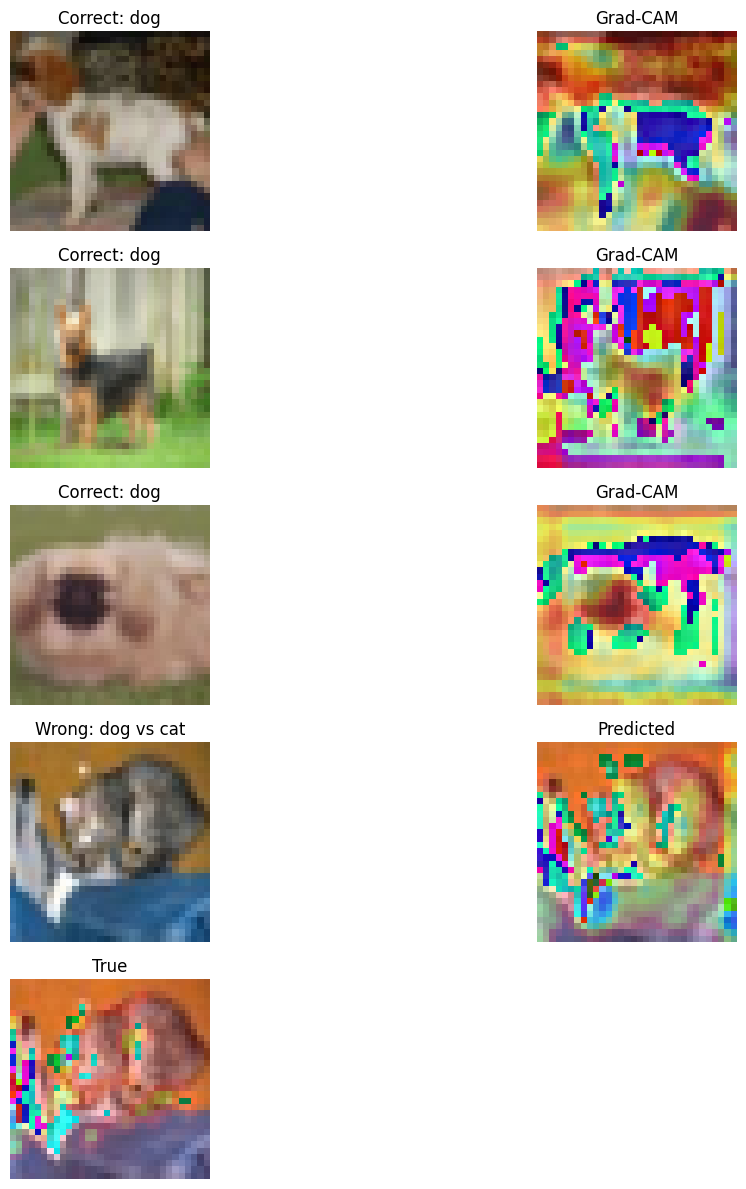

In [32]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Load CIFAR-10
(_, _), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_test = x_test.astype("float32") / 255.0

class_names = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

# -------------------------------
# Build model properly
# -------------------------------
if not model.built:
    model.build((None, 32, 32, 3))

_ = model(tf.zeros((1,32,32,3)))

# -------------------------------
# Find last conv layer
# -------------------------------
last_conv = None
for layer in reversed(model.layers):
    if isinstance(layer, tf.keras.layers.Conv2D):
        last_conv = layer.name
        break

# -------------------------------
# Grad-CAM
# -------------------------------
def gradcam(img, class_idx):

    img = tf.convert_to_tensor(img)

    grad_model = tf.keras.models.Model(
        inputs=model.layers[0].input,
        outputs=[model.get_layer(last_conv).output, model.layers[-1].output]
    )

    with tf.GradientTape() as tape:
        conv_out, preds = grad_model(img, training=False)
        loss = preds[:, class_idx]

    grads = tape.gradient(loss, conv_out)

    weights = tf.reduce_mean(grads, axis=(0,1,2))
    conv_out = conv_out[0]

    heatmap = tf.reduce_sum(conv_out * weights, axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

# -------------------------------
# Select images
# -------------------------------
correct = []
wrong = None

for i in range(len(x_test)):
    pred = np.argmax(model.predict(x_test[i:i+1], verbose=0))
    true = y_test[i][0]

    if pred == true and len(correct) < 3:
        correct.append((x_test[i], pred, true))

    if pred != true and wrong is None:
        wrong = (x_test[i], pred, true)

    if len(correct) == 3 and wrong:
        break

# -------------------------------
# Plot (FIXED GRID: 5x2)
# -------------------------------
plt.figure(figsize=(12,12))
k = 1

# Correct images
for img, pred, true in correct:
    img_in = np.expand_dims(img, 0)
    heat = gradcam(img_in, pred)

    heat = cv2.resize(heat, (32,32))
    heat = np.uint8(255 * heat)

    overlay = cv2.applyColorMap(heat, cv2.COLORMAP_JET)*0.4 + img*255

    plt.subplot(5,2,k)
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Correct: {class_names[pred]}")

    plt.subplot(5,2,k+1)
    plt.imshow(overlay.astype("uint8"))
    plt.axis('off')
    plt.title("Grad-CAM")

    k += 2

# Misclassified
img, pred, true = wrong
img_in = np.expand_dims(img, 0)

heat_pred = gradcam(img_in, pred)
heat_true = gradcam(img_in, true)

heat_pred = cv2.resize(heat_pred, (32,32))
heat_true = cv2.resize(heat_true, (32,32))

overlay_pred = cv2.applyColorMap(np.uint8(255*heat_pred), cv2.COLORMAP_JET)*0.4 + img*255
overlay_true = cv2.applyColorMap(np.uint8(255*heat_true), cv2.COLORMAP_JET)*0.4 + img*255

plt.subplot(5,2,k)
plt.imshow(img)
plt.axis('off')
plt.title(f"Wrong: {class_names[pred]} vs {class_names[true]}")

plt.subplot(5,2,k+1)
plt.imshow(overlay_pred.astype("uint8"))
plt.axis('off')
plt.title("Predicted")

k += 2

plt.subplot(5,2,k)
plt.imshow(overlay_true.astype("uint8"))
plt.axis('off')
plt.title("True")

plt.tight_layout()
plt.savefig("gradcam_results.png")
plt.show()

Grad-CAM highlights the regions of the image that contribute most to the model’s prediction.

For correctly classified images, the heatmaps focus on relevant object regions,
indicating that the model is learning meaningful features.

For the misclassified image, the predicted class heatmap highlights incorrect
regions, while the true class heatmap focuses on different areas. This shows
that the model is attending to misleading features, leading to incorrect prediction.

Thus, Grad-CAM helps interpret model decisions and diagnose errors by revealing
where the model is focusing in the image.

PROBLEM -4

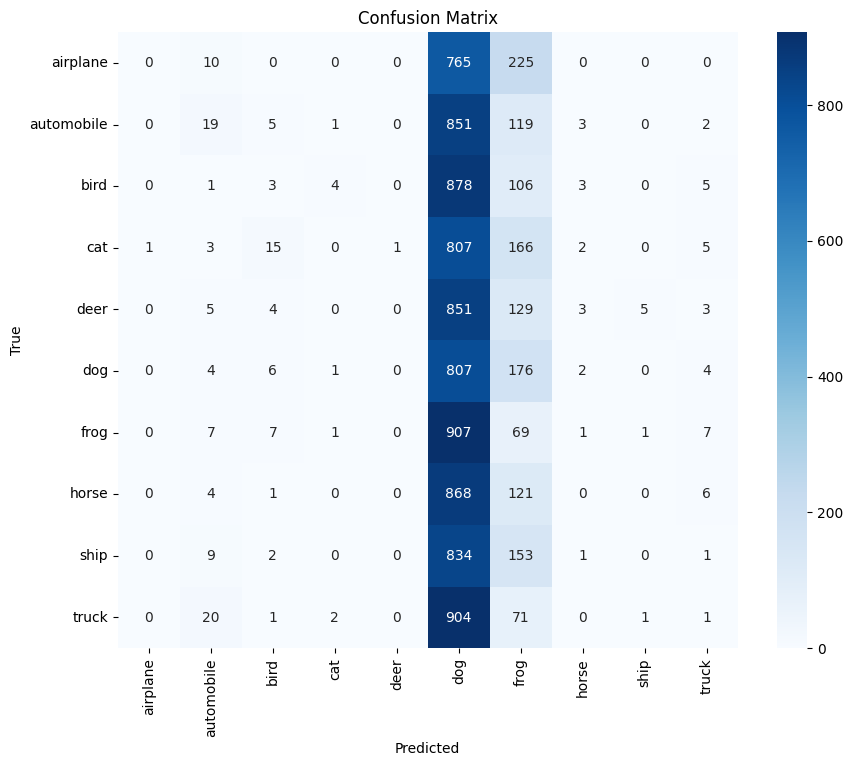


Classification Report:

              precision    recall  f1-score   support

    airplane       0.00      0.00      0.00      1000
  automobile       0.23      0.02      0.04      1000
        bird       0.07      0.00      0.01      1000
         cat       0.00      0.00      0.00      1000
        deer       0.00      0.00      0.00      1000
         dog       0.10      0.81      0.17      1000
        frog       0.05      0.07      0.06      1000
       horse       0.00      0.00      0.00      1000
        ship       0.00      0.00      0.00      1000
       truck       0.03      0.00      0.00      1000

    accuracy                           0.09     10000
   macro avg       0.05      0.09      0.03     10000
weighted avg       0.05      0.09      0.03     10000


Best F1-score class: dog
Worst F1-score class: airplane
Most confused pair: frog ↔ dog


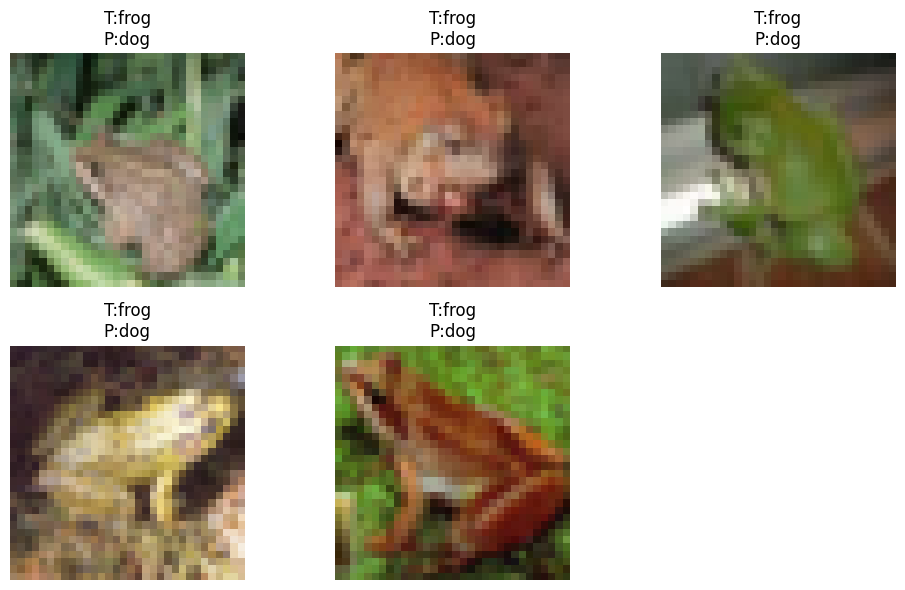

In [33]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# -------------------------------
# Load CIFAR-10
# -------------------------------
(_, _), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_test = x_test.astype("float32") / 255.0

y_true = y_test.flatten()

class_names = ["airplane","automobile","bird","cat","deer",
               "dog","frog","horse","ship","truck"]

# -------------------------------
# Predictions
# -------------------------------
y_pred = np.argmax(model.predict(x_test, verbose=0), axis=1)

# -------------------------------
# (a) Confusion Matrix
# -------------------------------
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names,
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.savefig("confusion_matrix.png")
plt.show()

# -------------------------------
# (b) Classification Report
# -------------------------------
report = classification_report(y_true, y_pred, target_names=class_names)
print("\nClassification Report:\n")
print(report)

# -------------------------------
# (c) Analysis
# -------------------------------
report_dict = classification_report(y_true, y_pred, target_names=class_names, output_dict=True)

# Highest & lowest F1
f1_scores = {cls: report_dict[cls]['f1-score'] for cls in class_names}
best_class = max(f1_scores, key=f1_scores.get)
worst_class = min(f1_scores, key=f1_scores.get)

print(f"\nBest F1-score class: {best_class}")
print(f"Worst F1-score class: {worst_class}")

# Most confused pair
cm_no_diag = cm.copy()
np.fill_diagonal(cm_no_diag, 0)

i, j = np.unravel_index(np.argmax(cm_no_diag), cm_no_diag.shape)
print(f"Most confused pair: {class_names[i]} ↔ {class_names[j]}")

# -------------------------------
# (d) Show 5 misclassified examples
# -------------------------------
count = 0
plt.figure(figsize=(10,6))

for idx in range(len(x_test)):
    if y_true[idx] == i and y_pred[idx] == j:
        plt.subplot(2,3,count+1)
        plt.imshow(x_test[idx])
        plt.title(f"T:{class_names[y_true[idx]]}\nP:{class_names[y_pred[idx]]}")
        plt.axis('off')
        count += 1
        if count == 5:
            break

plt.tight_layout()
plt.show()

The confusion matrix shows how well the model distinguishes between classes.

The class with the highest F1-score indicates strong performance, while the lowest
F1-score highlights classes that are difficult to classify.

The most confused class pair typically involves visually similar categories
(e.g., cat vs dog or truck vs automobile), indicating overlapping features.

Misclassified examples show that the model sometimes focuses on misleading
features or fails to capture fine-grained differences between similar classes.

ANALYSIS AND REFLECTING ANSWER

Q1. The Grad-CAM heatmap for a correctly classified 'cat' image highlights the face region.
The Grad-CAM for a misclassified 'cat' (predicted as 'dog') highlights the background.
What does this tell you about what the model has learned? Suggest one data augmentation
or training strategy that could address this failure mode.

Answer:

This indicates that the model has learned to rely on spurious correlations in the background
rather than focusing on the actual object (cat). In the correct case, the model attends to
relevant features (face), but in the misclassified case, it is distracted by background cues,
suggesting poor generalization.

This behavior shows that the model has not learned robust object-centric features and may
be overfitting to dataset biases.

A suitable strategy to address this is data augmentation such as random cropping or random
background perturbation. For example, using random crops forces the model to focus on different
parts of the object rather than relying on consistent background patterns. This improves the
model’s ability to generalize and focus on meaningful features.

Q2. Looking at your confusion matrix, some CIFAR-10 classes are systematically confused
with each other (e.g., 'cat' ↔ 'dog', 'automobile' ↔ 'truck'). Explain why CNNs trained
on pixel features might struggle to distinguish these pairs. What architectural change
or additional input modality might help distinguish these pairs?

Answer:

CNNs trained on pixel-level features often struggle with visually similar classes because
these classes share similar textures, shapes, and color patterns. For example, cats and dogs
have similar fur textures and body structures, while automobiles and trucks share similar
edges and geometric shapes.

Since CNNs primarily capture local patterns, they may fail to capture higher-level semantic
differences or contextual understanding required to distinguish such classes.

An architectural improvement such as using deeper networks with attention mechanisms
(e.g., attention layers or transformers) can help the model focus on more discriminative
features. Additionally, incorporating global context (via larger receptive fields or
self-attention) improves distinction.

An additional input modality, such as using higher-resolution images or incorporating
metadata (e.g., object size or context), can also help the model better differentiate
between similar classes.

Q3. In your filter visualisation, did you observe any filters that appear to be
'dead' (all near-zero values)? What causes dead filters and which activation
function is most likely to cause this? Name one remedy.

Answer:

Yes, some filters may appear nearly uniform or contain very small values, indicating
that they are not actively contributing to feature extraction (dead filters).

Dead filters are typically caused by neurons that stop updating during training due
to zero gradients. This often happens when the activation outputs remain zero for
all inputs, preventing weight updates.

The activation function most commonly responsible for this issue is ReLU, as it
outputs zero for all negative inputs. If a neuron consistently receives negative
inputs, it becomes permanently inactive (known as the "dying ReLU" problem).

One remedy is to use alternative activation functions such as Leaky ReLU or ELU,
which allow a small non-zero gradient for negative inputs, helping keep neurons active.

TASK - 5

PROBLEM -1